In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn.preprocessing

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [58]:
data = pd.read_csv("Transaction data for Segmentation copy.csv")
data

,CustomerID,Month,Brand,Year,Sales
0,10000,5,B4,2021,21830.69
1,10000,10,B5,2021,7221.56
2,10000,8,B1,2021,29684.44
3,10000,10,B3,2021,1573.06
4,10000,1,B2,2020,4016.70
...,...,...,...,...,...
499995,99998,12,B3,2020,7231.77
499996,99998,3,B3,2020,27098.23
499997,99998,12,B1,2020,65831.61
499998,99999,6,B2,2021,3627.16


In [59]:
# creating a subset for year 2021
df = data.query('Year == 2021')
data.head()

,CustomerID,Month,Brand,Year,Sales
0,10000,5,B4,2021,21830.69
1,10000,10,B5,2021,7221.56
2,10000,8,B1,2021,29684.44
3,10000,10,B3,2021,1573.06
4,10000,1,B2,2020,4016.70


In [60]:
df['Year'].unique()

array([2021])

In [61]:
# Sales_21
df1 = df.groupby(['CustomerID'])['Sales'].sum().reset_index()
df1.rename(columns = {'Sales': 'Sales_21'}, inplace = True)
df1

,CustomerID,Sales_21
0,10000,60309.75
1,10001,68859.11
2,10004,69956.96
3,10005,9233.57
4,10006,93586.85
...,...,...
84389,99995,152032.49
84390,99996,106558.42
84391,99997,98744.25
84392,99998,17968.88


In [62]:
# Sales_B1_21
df2 = df.query('Brand == "B1"').groupby(['CustomerID'])['Sales'].sum().reset_index()
df2.rename(columns = {'Sales' : 'Sales_B1_21'}, inplace = True)
df2

,CustomerID,Sales_B1_21
0,10000,29684.44
1,10001,26593.40
2,10004,6824.23
3,10006,7789.73
4,10010,11057.63
...,...,...
37695,99991,51928.15
37696,99994,37534.86
37697,99995,42573.47
37698,99996,28506.06


In [63]:
# buying frequency
df3 = df.groupby('CustomerID')['Month'].nunique().reset_index()
df3.rename(columns = {'Month': 'Buying_Freq21'}, inplace = True)
df3

,CustomerID,Buying_Freq21
0,10000,3
1,10001,4
2,10004,3
3,10005,2
4,10006,5
...,...,...
84389,99995,7
84390,99996,4
84391,99997,4
84392,99998,2


In [64]:
# buying frequency by brand B1
df4 = df.query('Brand == "B1"').groupby('CustomerID')['Month'].nunique().reset_index()
df4.rename(columns = {'Month': 'Buying_FreqB121'}, inplace = True)
df4

,CustomerID,Buying_FreqB121
0,10000,1
1,10001,2
2,10004,1
3,10006,1
4,10010,1
...,...,...
37695,99991,1
37696,99994,1
37697,99995,2
37698,99996,2


In [65]:
# Number of brands purchased
df5 = df.groupby('CustomerID')['Brand'].nunique().reset_index()
df5.rename(columns = {'Brand': 'BrandEng_21'},inplace = True)
df5

,CustomerID,BrandEng_21
0,10000,4
1,10001,2
2,10004,3
3,10005,2
4,10006,4
...,...,...
84389,99995,4
84390,99996,3
84391,99997,2
84392,99998,2


In [66]:
# B1 Puhase in 2021 combine into one df
finaldf = pd.merge(pd.merge(pd.merge(pd.merge(df1, df2, on = ['CustomerID'], how = 'outer'), df3, on = ['CustomerID'], how = 'outer'), df4, on = ['CustomerID'], how = 'outer'),df5, on = ['CustomerID'], how = 'outer')
finaldf

,CustomerID,Sales_21,Sales_B1_21,Buying_Freq21,Buying_FreqB121,BrandEng_21
0,10000,60309.75,29684.44,3,1.0,4
1,10001,68859.11,26593.40,4,2.0,2
2,10004,69956.96,6824.23,3,1.0,3
3,10005,9233.57,NaN,2,NaN,2
4,10006,93586.85,7789.73,5,1.0,4
...,...,...,...,...,...,...
84389,99995,152032.49,42573.47,7,2.0,4
84390,99996,106558.42,28506.06,4,2.0,3
84391,99997,98744.25,NaN,4,NaN,2
84392,99998,17968.88,8971.28,2,1.0,2


In [67]:
finaldf['B121_Contribution'] =(finaldf['Sales_B1_21']/finaldf['Sales_21'])*100
finaldf

,CustomerID,Sales_21,Sales_B1_21,Buying_Freq21,Buying_FreqB121,BrandEng_21,B121_Contribution
0,10000,60309.75,29684.44,3,1.0,4,49.219969
1,10001,68859.11,26593.40,4,2.0,2,38.620017
2,10004,69956.96,6824.23,3,1.0,3,9.754898
3,10005,9233.57,NaN,2,NaN,2,NaN
4,10006,93586.85,7789.73,5,1.0,4,8.323530
...,...,...,...,...,...,...,...
84389,99995,152032.49,42573.47,7,2.0,4,28.002876
84390,99996,106558.42,28506.06,4,2.0,3,26.751579
84391,99997,98744.25,NaN,4,NaN,2,NaN
84392,99998,17968.88,8971.28,2,1.0,2,49.926762


In [68]:
# Replace NAN to 0
finaldf = finaldf.fillna(0)
finaldf

,CustomerID,Sales_21,Sales_B1_21,Buying_Freq21,Buying_FreqB121,BrandEng_21,B121_Contribution
0,10000,60309.75,29684.44,3,1.0,4,49.219969
1,10001,68859.11,26593.40,4,2.0,2,38.620017
2,10004,69956.96,6824.23,3,1.0,3,9.754898
3,10005,9233.57,0.00,2,0.0,2,0.000000
4,10006,93586.85,7789.73,5,1.0,4,8.323530
...,...,...,...,...,...,...,...
84389,99995,152032.49,42573.47,7,2.0,4,28.002876
84390,99996,106558.42,28506.06,4,2.0,3,26.751579
84391,99997,98744.25,0.00,4,0.0,2,0.000000
84392,99998,17968.88,8971.28,2,1.0,2,49.926762


In [69]:
# dropping customerID column for clustering
finaldf.drop(['CustomerID'], axis = 1, inplace = True)
finaldf

,Sales_21,Sales_B1_21,Buying_Freq21,Buying_FreqB121,BrandEng_21,B121_Contribution
0,60309.75,29684.44,3,1.0,4,49.219969
1,68859.11,26593.40,4,2.0,2,38.620017
2,69956.96,6824.23,3,1.0,3,9.754898
3,9233.57,0.00,2,0.0,2,0.000000
4,93586.85,7789.73,5,1.0,4,8.323530
...,...,...,...,...,...,...
84389,152032.49,42573.47,7,2.0,4,28.002876
84390,106558.42,28506.06,4,2.0,3,26.751579
84391,98744.25,0.00,4,0.0,2,0.000000
84392,17968.88,8971.28,2,1.0,2,49.926762


In [70]:
# Standarize the data using scale()
df_scaled = sklearn.preprocessing.scale(finaldf)
df_scaled

array([[ 0.03426138,  0.95336768,  0.28244253,  0.60188426,  1.71624272,
         0.99641554],
       [ 0.24221196,  0.79131458,  1.05978584,  1.98742804, -0.28069086,
         0.64072867],
       [ 0.26891554, -0.24511825,  0.28244253,  0.60188426,  0.71777593,
        -0.32785536],
       ...,
       [ 0.96912392, -0.60289027,  1.05978584, -0.78365952, -0.28069086,
        -0.65518602],
       [-0.99561784, -0.13255545, -0.49490078,  0.60188426, -0.28069086,
         1.02013237],
       [-0.68413856, -0.60289027, -0.49490078, -0.78365952, -0.28069086,
        -0.65518602]], shape=(84394, 6))

In [71]:
len(df_scaled)

84394

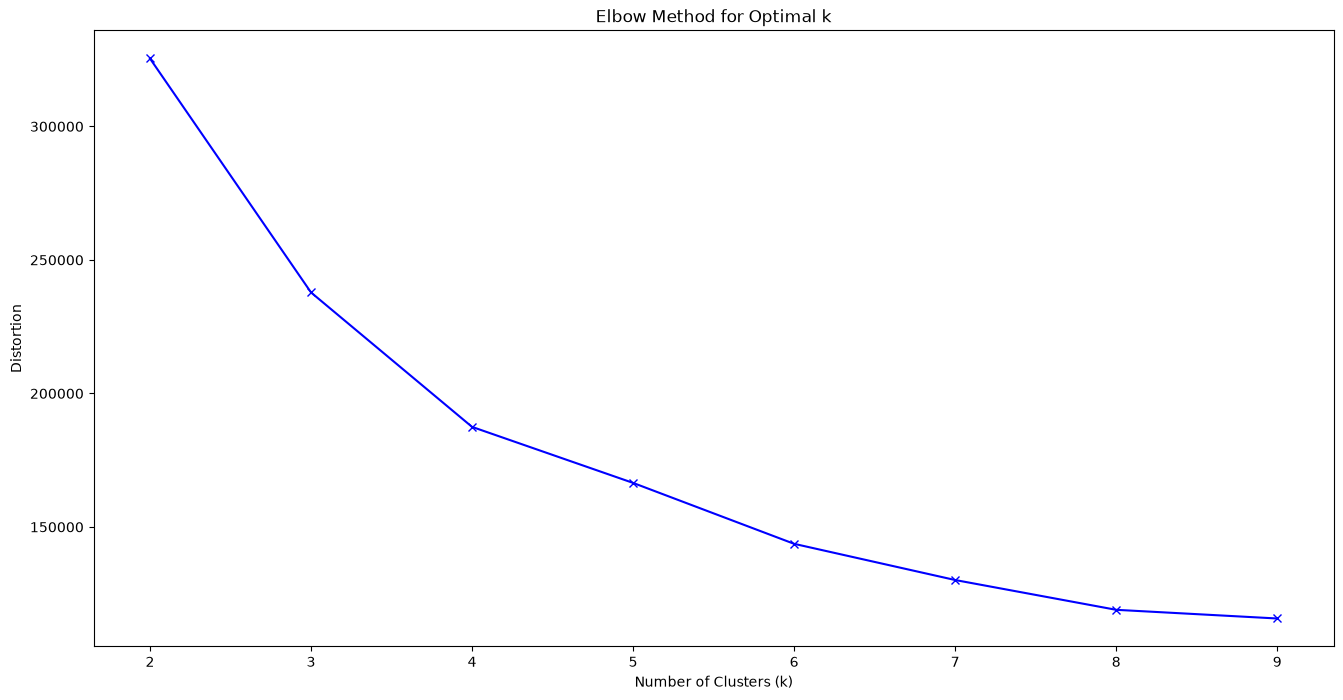

In [72]:
# Create plot for elbow method to find optimal number of clusters
distortions = []
K = range(2,10)
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(df_scaled)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(16,8))
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('Elbow Method for Optimal k')
plt.show()


In [73]:
# Running K Means model
CL = KMeans(n_clusters=4, random_state=3425)
CL.fit(df_scaled)

# compute centroids
centroids = CL.cluster_centers_
centroids

array([[-0.62382661, -0.58876047, -0.72858179, -0.70057663, -0.75323443,
        -0.62581686],
       [ 1.31287504,  1.75454168,  1.16346878,  1.47523886,  1.045437  ,
         0.76934308],
       [ 0.5200793 , -0.38585498,  0.72697421, -0.18588656,  0.77865471,
        -0.44459507],
       [-0.4867553 ,  0.74620901, -0.49010027,  0.87840917, -0.42925669,
         1.74500442]])

In [74]:
# add cluster labels to the original dataframe
segment = pd.DataFrame(CL.labels_)
custsales = finaldf.assign(segment = segment)
custsales['segment'] = custsales ['segment'] +1 
custsales.head()

,Sales_21,Sales_B1_21,Buying_Freq21,Buying_FreqB121,BrandEng_21,B121_Contribution,segment
0,60309.75,29684.44,3,1.0,4,49.219969,2
1,68859.11,26593.40,4,2.0,2,38.620017,2
2,69956.96,6824.23,3,1.0,3,9.754898,3
3,9233.57,0.00,2,0.0,2,0.000000,1
4,93586.85,7789.73,5,1.0,4,8.323530,3


In [75]:
len(custsales)

84394

In [76]:
# computing cluster size
custsales.groupby('segment')['segment'].count()

segment
1    34002
2    11127
3    25486
4    13779
Name: segment, dtype: int64

In [77]:
pca = PCA().fit(df_scaled)
val = PCA().fit_transform(df_scaled)
pca_df = pd.DataFrame(val)
pca_df = pca_df[[0,1]]
pca_df.columns = ['Dim1','Dim2']
finaldata = pd.concat([custsales, pca_df], axis = 1)
finaldata

,Sales_21,Sales_B1_21,Buying_Freq21,Buying_FreqB121,BrandEng_21,B121_Contribution,segment,Dim1,Dim2
0,60309.75,29684.44,3,1.0,4,49.219969,2,1.818920,0.276034
1,68859.11,26593.40,4,2.0,2,38.620017,2,1.881767,0.886654
2,69956.96,6824.23,3,1.0,3,9.754898,3,0.581660,-0.574651
3,9233.57,0.00,2,0.0,2,0.000000,1,-1.633986,-0.104992
4,93586.85,7789.73,5,1.0,4,8.323530,3,1.878717,-1.815772
...,...,...,...,...,...,...,...,...,...
84389,152032.49,42573.47,7,2.0,4,28.002876,2,4.756426,-1.479856
84390,106558.42,28506.06,4,2.0,3,26.751579,2,2.580804,-0.028901
84391,98744.25,0.00,4,0.0,2,0.000000,3,-0.094044,-1.489252
84392,17968.88,8971.28,2,1.0,2,49.926762,4,-0.207534,1.393337


<Axes: xlabel='Dim1', ylabel='Dim2'>

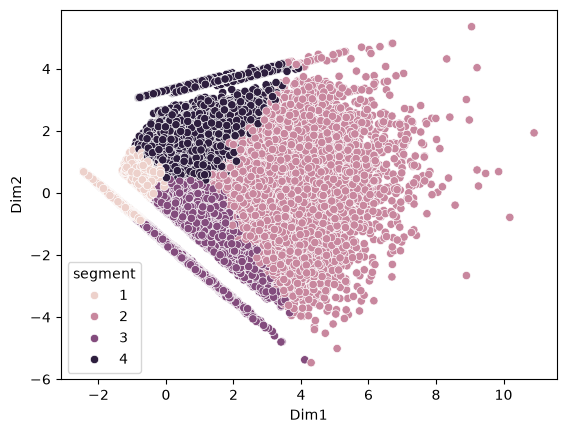

In [78]:
sns.scatterplot(x=finaldata['Dim1'],y=finaldata['Dim2'] ,hue = finaldata['segment'])

In [79]:
pca = PCA(n_components=2)
pca.fit(df_scaled)
print(pca.explained_variance_ratio_)

[0.52467703 0.30618769]


In [80]:
seg_analysis = custsales.groupby('segment')[['Sales_21', 'Sales_B1_21', 'Buying_Freq21', 'Buying_FreqB121',
       'BrandEng_21', 'B121_Contribution']].mean().reset_index().round(2)
seg_analysis

,segment,Sales_21,Sales_B1_21,Buying_Freq21,Buying_FreqB121,BrandEng_21,B121_Contribution
0,1,33269.33,269.70,1.70,0.06,1.53,0.87
1,2,112964.79,45024.57,4.13,1.63,3.33,42.48
2,3,80303.48,4153.16,3.57,0.43,3.06,6.29
3,4,38907.65,25727.36,2.01,1.20,1.85,71.49


In [81]:
col_list = ['Sales_2021', 'Sales_Coffee_in_2021', 'Buying_Frequency in 2021', 'Buying_Frequency_for_Coffee_in_2021', 'Buying_Frequency_of_Brand in 2021', 'Coffee_Sales_Contribution']

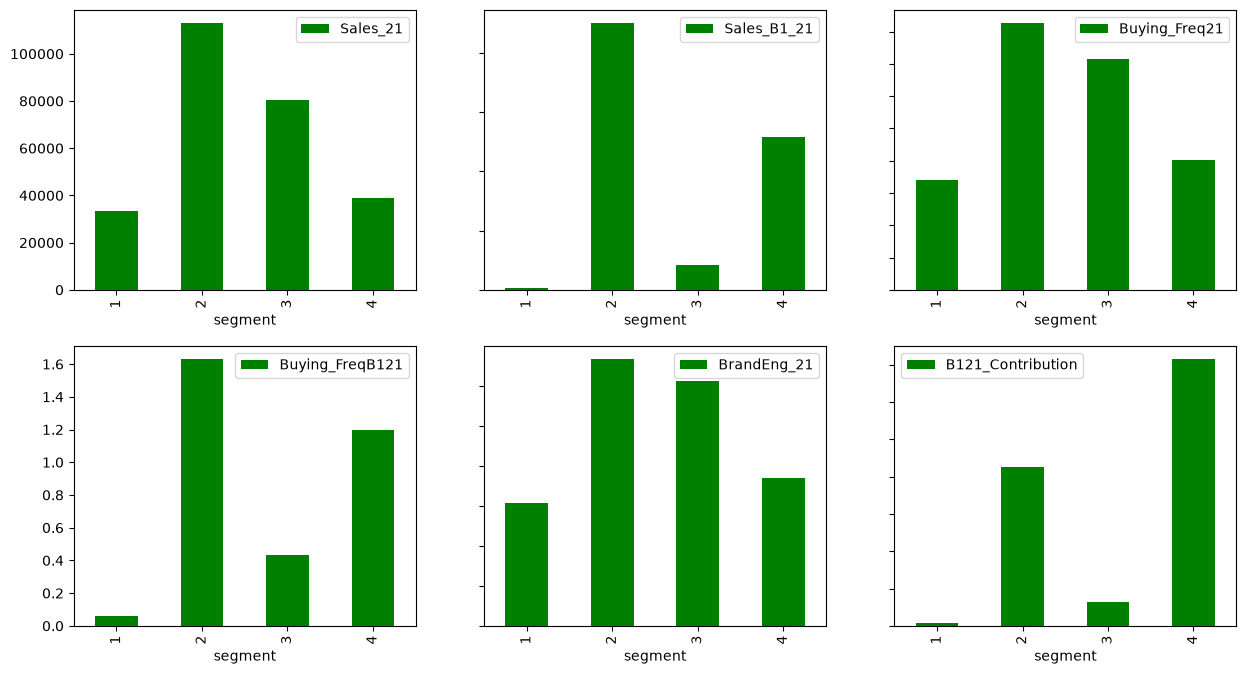

In [31]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15,8))
axe = axes.ravel()

for i, cols in enumerate(col_list):
    seg_analysis.plot.bar('segment', cols, color = 'green', ax=axe[i], sharey=True)